# 06. epitope potential（絶対量・射影順序の修正・上流ゲート付き）

3rd paper の Fig3 にあたる計算。2026-08-02 に2つの誤りを直した版。

## 直した点1: 射影の順序

律速ロジック（ステップ間 min）は発現**レベル**に対して定義されているのに、
以前は**変化量 Δ(z-score)** に適用していた。射影は非線形なので順序が結果を変える。

```
誤: Δ発現 → max/min射影 → Δエピトープ
正: 処理後レベル → 射影 → エピトープ量(処理後)
    対照レベル   → 射影 → エピトープ量(対照)
    差を取る    → Δエピトープ
```

## 直した点2: 上流をゲートとして使う（設計案D）

辞書（GlycoEpitope DB 由来）は「決定基を作る**最終反応の酵素だけ**」を持っており、
52エピトープ中44が1ステップ・大半が1遺伝子だった。GD2 なら B4GALNT1 のみで、
実際に必要な UGCG → B4GALT6 → ST3GAL5 → ST8SIA1 が繋がっていない。

`scripts/build_enzyme_dag.py` で GlycoEnzOnto の反応ルール（Reactant → Product）から
酵素DAG（353酵素・6,597辺）を作り、上流を辿れるようにした。

ただし**上流を min に入れるのは誤り**だった。生の発現量に min を掛けると
「どちらの酵素がたまたま多く発現しているか」で律速が決まってしまう
（発現量の絶対値は酵素間で比較できない）。4案を分割再現性で比較した結果
（`scripts/compare_epitope_designs.py`、詳細は `docs/epitope_potential_design.md`）、

> **上流は min に入れず、「基質があるか」の門としてのみ使う（案D）**

を採用した。再現性の差が 0.525 と最良で、信号量も末端のみの8割を保つ。

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

ROOT = Path.cwd()
while not (ROOT / 'data').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
FIGDIR, TABDIR = ROOT / 'results' / 'figures', ROOT / 'results' / 'tables'
TABDIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    """成果物ごとのフォルダに PNG/PDF/SVG を保存する"""
    outdir = FIGDIR / name
    outdir.mkdir(parents=True, exist_ok=True)
    for ext in ('png', 'pdf', 'svg'):
        plt.savefig(outdir / f'{name}.{ext}', dpi=200, bbox_inches='tight')

print(ROOT)

/Users/koreedatatsuya/research/glyco_epitope_3rd_paper


## 1. 辞書：末端酵素 ＋ DAG による上流

In [2]:
term = pd.read_csv(ROOT / 'data/processed/epitope_step_gene.csv')      # 末端（GlycoEpitope DB）
dag  = pd.read_csv(ROOT / 'data/processed/glycoenzonto_enzyme_dag.csv')  # 酵素DAG
UP   = dag.groupby('GENE').UPSTREAM_GENE.apply(set).to_dict()
print(f"末端: {len(term)}行 / {term.EPITOPE_NAME.nunique()}エピトープ")
print(f"DAG : {dag.GENE.nunique()}酵素 / {len(dag):,}辺")

末端: 98行 / 52エピトープ
DAG : 291酵素 / 6,597辺


## 2. 絶対量レベル（処理後・対照）

In [3]:
trt = pd.read_parquet(ROOT / 'data/processed/abs_glyco_16cell_24h.parquet')
META = ['cell', 'pertname', 'timepoint', 'dose', 'idx']
ctl = pd.read_csv(ROOT / 'data/processed/ctl_glyco_baseline.csv', low_memory=False)
ctl['cell'] = ctl.SAMPLE_ID.str.split('_').str[1]
PANEL = sorted(set(c for c in trt.columns if c not in META) & set(ctl.columns))
CELLS = sorted(set(trt.cell) & set(ctl.cell))
print(f"処理後 {len(trt):,}試料 / 対照 {len(ctl):,}試料 / パネル {len(PANEL)}遺伝子 / 細胞 {len(CELLS)}")

処理後 69,918試料 / 対照 6,400試料 / パネル 385遺伝子 / 細胞 16


## 3. 重複エピトープの畳み込み

辞書には**遺伝子集合が完全に一致するエピトープ**がある（GD2 と N-Acetyl GM2 はどちらも B4GALNT1）。
そのまま並べると同じ値の列が増えて表が水増しされるので、代表1つにまとめて別名を記録する。

In [4]:
sets = term.groupby('EPITOPE_NAME').HGNC_SYMBOL.apply(lambda s: frozenset(s) & set(PANEL))
sets = sets[sets.apply(len) > 0]
rep, alias = {}, {}
for epi, gs in sets.items():
    if gs in rep:
        alias.setdefault(rep[gs], []).append(epi)
    else:
        rep[gs] = epi
EPIS = sorted(rep.values())
print(f"{len(sets)} エピトープ → 代表 {len(EPIS)} 件に畳み込み")
for r, a in alias.items():
    print(f"  {r}  ← {', '.join(a)}")

52 エピトープ → 代表 39 件に畳み込み
  6'-Sulfo Sialyl Lewis x  ← 6,6'- Disulfo Sialyl Lewis x, Sialyl 6-Sulfo Lewis x
  Asialo GM1  ← GD1b, GM1
  GD1a  ← GM1b, GT1b, Monosialyl Gb5, SSEA-4
  GQ1b  ← GT1a
  GQ1b alpha  ← GT1a alpha
  GD2  ← N-Acetyl GM2
  Gb3  ← Pk Antigen
  3'-Sulfo Lewis a  ← SM4s


## 4. 射影（案D）

- **値**：末端酵素のレベル（アイソ酵素は max ＝ 冗長性）
- **ゲート**：上流ステップの最大発現がパネル中央値を下回る細胞では、
  そのエピトープは「基質が無い＝作れない」と判定して無効にする

In [5]:
def upstream_of(epi):
    seeds = set(term[term.EPITOPE_NAME == epi].HGNC_SYMBOL)
    up = set()
    for x in seeds:
        up |= UP.get(x, set())
    return sorted((up - seeds) & set(PANEL))

TERM_G = {e: sorted(sets[e]) for e in EPIS}
UP_G   = {e: upstream_of(e) for e in EPIS}

def epitope_level(levels):
    return pd.DataFrame({e: levels[TERM_G[e]].max(axis=1) for e in EPIS})

delta, gate = {}, {}
for cell in CELLS:
    t = trt[trt.cell == cell].groupby('pertname')[PANEL].mean()
    c = ctl[ctl.cell == cell][PANEL].median()
    thr = float(c.median())
    gate[cell] = {e: (not UP_G[e]) or float(c[UP_G[e]].max()) >= thr for e in EPIS}
    d = epitope_level(t) - epitope_level(c.to_frame().T).iloc[0]
    delta[cell] = d.loc[:, [gate[cell][e] for e in d.columns]]

print({c: f"{delta[c].shape[1]}/{len(EPIS)}エピトープ通過" for c in ['HEPG2', 'A549', 'MCF7']})

{'HEPG2': '34/39エピトープ通過', 'A549': '39/39エピトープ通過', 'MCF7': '34/39エピトープ通過'}


### ゲートの妥当性：HepG2 で落ちるのは何か

In [6]:
off = [e for e in EPIS if not gate['HEPG2'][e]]
print(f"HEPG2 でゲートに落ちた {len(off)}/{len(EPIS)} 件:")
for e in off:
    print(f"  {e:28s} 上流 {', '.join(UP_G[e][:6])}")
print()
print("→ GD2 が落ちるのは正しい。GD2 は神経外胚葉系（神経芽腫・メラノーマ）の抗原で、肝細胞は作らない。")
print("   辞書に何も教えていないのに、ゲートがこれを再現している。")

HEPG2 でゲートに落ちた 5/39 件:
  3'-Sulfo Lewis a             上流 A4GALT, B3GALNT1, B3GNT5, B4GALNT1, B4GALT6, ST3GAL5
  GD2                          上流 A4GALT, B3GALNT1, B3GNT5, B4GALT6, ST3GAL5, ST8SIA1
  Galactosylgloboside          上流 A4GALT, B3GALNT1, B3GNT5
  Gb3                          上流 B3GALNT1, B3GNT5, B4GALNT1, B4GALT6, ST3GAL5, ST8SIA1
  N-Acetyl GM3                 上流 A4GALT, B3GALNT1, B3GNT5, B4GALNT1, B4GALT6, ST8SIA1

→ GD2 が落ちるのは正しい。GD2 は神経外胚葉系（神経芽腫・メラノーマ）の抗原で、肝細胞は作らない。
   辞書に何も教えていないのに、ゲートがこれを再現している。


## 5. 候補表（案D・HepG2）

In [7]:
CELL = 'HEPG2'
d = delta[CELL]
cand = pd.DataFrame({
    'alias':   [', '.join(alias.get(e, [])) for e in d.columns],
    'n_gene':  [len(TERM_G[e]) for e in d.columns],
    'n_upstream': [len(UP_G[e]) for e in d.columns],
    'n_2x':    (d.abs() >= 1).sum(),
    'n_2x_up': (d >= 1).sum(),
    'n_2x_dn': (d <= -1).sum(),
    'max_up':  d.max(),
    'max_dn':  d.min(),
}, index=d.columns).sort_values('n_2x', ascending=False)
cand['pct'] = (100 * cand.n_2x / len(d)).round(1)
cand.index.name = 'epitope'
cand.to_csv(TABDIR / f'epitope_druggability_{CELL.lower()}_gated.csv')
print(f'{CELL}: {len(d)}薬 × {d.shape[1]}エピトープ（ゲート通過）')
cand.head(15)[['n_gene', 'n_upstream', 'n_2x', 'pct', 'n_2x_up', 'n_2x_dn', 'max_up', 'max_dn']].round(2)

HEPG2: 175薬 × 34エピトープ（ゲート通過）


,n_gene,n_upstream,n_2x,pct,n_2x_up,n_2x_dn,max_up,max_dn
epitope,,,,,,,,
T Antigen,1,26,70,40.0,70,0,1.50,-0.58
Chondroitin-4-Sulfate,1,6,49,28.0,5,44,1.83,-1.71
"beta1,6-GlcNAc Branching",1,2,45,25.7,41,4,1.71,-1.26
O-GlcNAc,1,52,44,25.1,36,8,1.77,-1.85
HNK-1,3,19,38,21.7,37,1,1.26,-1.04
Chondroitin-6-Sulfate,2,9,19,10.9,13,6,1.53,-1.65
Chondroitin,2,4,19,10.9,13,6,2.56,-1.32
Lactosylceramide,1,12,15,8.6,7,8,1.21,-1.42
O-Fucose Glycan /EGF Repeat,3,29,13,7.4,6,7,1.31,-1.21


In [8]:
long = (d.stack().rename('delta_log2').reset_index()
          .rename(columns={'level_0': 'pertname', 'level_1': 'epitope'}))
long = long[long.delta_log2.abs() >= 1].copy()
long['direction'] = np.where(long.delta_log2 > 0, 'up', 'down')
long['fold'] = (2 ** long.delta_log2).round(2)
long = long.sort_values('delta_log2', key=abs, ascending=False)
long.to_csv(TABDIR / f'drug_epitope_candidates_{CELL.lower()}_gated.csv', index=False)
print(f'閾値(2倍)を越える 薬×エピトープ: {len(long):,} 組')
long.head(12)

閾値(2倍)を越える 薬×エピトープ: 396 組


,pertname,epitope,delta_log2,direction,fold
344,azacitidine,Chondroitin,2.560827,up,5.90
375,belinostat,6'-Sulfo Sialyl Lewis x,2.384354,up,5.22
258,aspirin,N-Acetyl GD3,2.319384,up,4.99
251,aspirin,GT3,2.319384,up,4.99
360,azacitidine,N-Acetyl GD3,2.039251,up,4.11
353,azacitidine,GT3,2.039251,up,4.11
603,bosutinib,Paragloboside,1.956136,up,3.88
378,belinostat,Chondroitin,1.944881,up,3.85
582,bosutinib,Chondroitin,1.871176,up,3.66
377,belinostat,Bisecting GlcNAc,1.860069,up,3.63


## 6. Fig3 候補：薬剤 × エピトープ の Δ ヒートマップ（ゲート後）

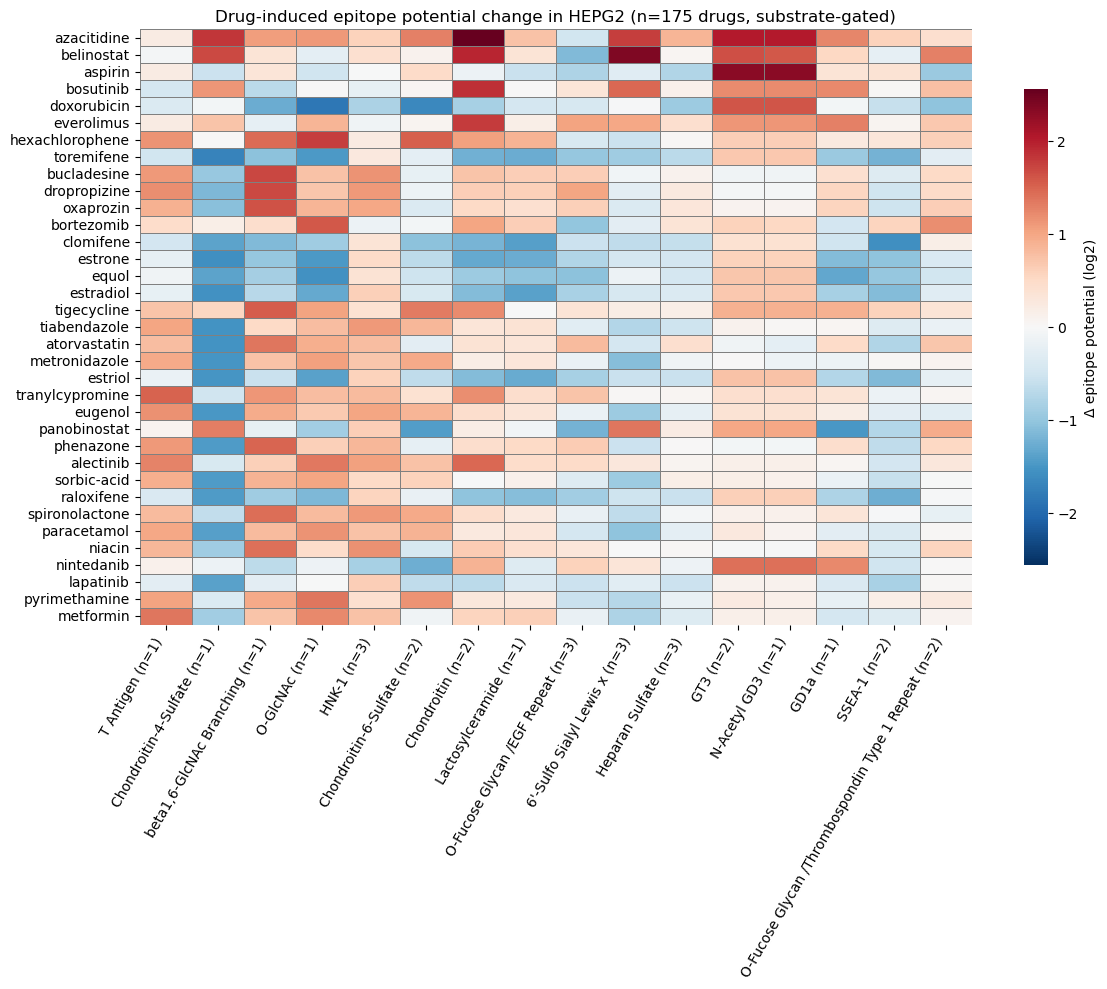

In [9]:
top_epi  = cand[cand.n_2x > 0].index[:16]
top_drug = d[top_epi].abs().max(axis=1).nlargest(35).index
hm = d.loc[top_drug, top_epi]

fig, ax = plt.subplots(figsize=(12, 10))
vmax = np.abs(hm.values).max()
sns.heatmap(hm, ax=ax, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
            linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Δ epitope potential (log2)', 'shrink': 0.8})
ax.set_xlabel(''); ax.set_ylabel('')
ax.set_title(f'Drug-induced epitope potential change in {CELL} '
             f'(n={len(d)} drugs, substrate-gated)')
ax.set_xticklabels([f'{e} (n={cand.loc[e, "n_gene"]})' for e in top_epi])
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
savefig('fig_epitope_delta_hepg2_gated')
plt.show()

## 所見

- **ゲートが GD2 系を落とす**。案A（末端のみ）では GD2 が「175薬中32本が2倍以上動かす」と出て
  ヒートマップで最も目立っていたが、HepG2 は GD2 を作れないのでこれはアーティファクトだった。
  現行551組のうち **104組（19%）がゲート落ちエピトープ由来**。
- 重複エピトープ（GD2 / N-Acetyl GM2 など）を代表1つに畳み込んだので、表の水増しも解消した。
- 残る課題：ゲート閾値（パネル中央値）の感度分析、6h（HepG2 は590薬）での再現確認、
  上位に来る Chondroitin 系・O-GlcNAc が汎ストレスの代理でないかの検証。